# Importação de Bibliotecas

Atenção: este notebook é apenas para exploração e análise.

Para treinar o modelo e salvar os resultados, execute o script train.py

Nesta etapa foram importadas as bibliotecas necessárias para o desenvolvimento do projeto, incluindo manipulação e análise dos dados com **Pandas** e **NumPy**, construção de pipelines e pré-processamento com **Scikit-learn**, treinamento de modelos de Machine Learning, avaliação das métricas e otimização de hiperparâmetros com **Optuna**.

Também foram definidas funções auxiliares para o cálculo do **MAPE (Mean Absolute Percentage Error)** e para identificar variáveis numéricas não binárias, que serão utilizadas nas etapas de pré-processamento e modelagem.

In [1]:
import sqlalchemy
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\patry\AppData\Local\miniconda3\envs\ds_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def mean_absolute_percentage_error(y_true, y_pred):
    """Calcula o MAPE ignorando zeros em y_true."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def is_nonbinary_numeric(col):
    # Verifica se coluna é numérica não binária (exclui categóricas e target)
    if col in categorical_cols or col == 'Target':
        return False
    unique_vals = X_train[col].nunique(dropna=True)
    if unique_vals <= 2:
        return False
    return pd.api.types.is_numeric_dtype(X_train[col])


# Amostragem


Nesta etapa, os dados foram carregados a partir da **Feature Store**, utilizando a ABT definida em `abt.sql`. Após a remoção dos registros sem valor na variável **Target**, a base final possui **876.540 registros e 240 variáveis**.

Como se trata de um problema de previsão temporal, os dados foram ordenados pela **DtRef** e divididos cronologicamente em **60% para treino, 20% para validação e 20% para teste**, evitando o uso de informações futuras durante o treinamento.

Por fim, foram separadas as variáveis preditoras (**X**) e a variável alvo (**y**), removendo da modelagem as colunas `Target`, `IdStore` e `DtRef`.

In [ ]:
# Carrega a base de dados principal
df = pd.read_csv("train.csv")

In [ ]:
# Conecta ao banco e carrega a ABT do feature store
engine = sqlalchemy.create_engine("sqlite:///../../../data/feature_store.db")
with open("abt.sql", "r") as file:
    abt_query = file.read()
df = pd.read_sql(abt_query, engine)

In [ ]:
# Visualiza as primeiras linhas do dataframe
df.head()

,DtRef,IdStore,QtdSales7d,QtdSales14d,QtdSales28d,QtdSales42d,QtdSales56d,QtdSales84d,AvgSales7d,AvgSales14d,...,DaysSchoolHoliday56d,DaysSchoolHoliday84d,DaysSchoolHolidayRate7d,DaysSchoolHolidayRate14d,DaysSchoolHolidayRate28d,DaysSchoolHolidayRate42d,DaysSchoolHolidayRate56d,DaysSchoolHolidayRate84d,MonthsSinceCompetition,Target
0,2013-03-26,1,35178.0,65480.0,130434.0,190894.0,255712.0,371108,5863.000000,5456.666667,...,1,12,0.142857,0.071429,0.035714,0.023810,0.017857,0.142857,54.0,168765.0
1,2013-03-26,2,34387.0,59946.0,118145.0,171940.0,227987.0,330911,5731.166667,4995.500000,...,6,10,0.142857,0.071429,0.035714,0.142857,0.107143,0.119048,64.0,161514.0
2,2013-03-26,3,49165.0,87382.0,170497.0,247326.0,330148.0,479824,8194.166667,7281.833333,...,1,5,0.142857,0.071429,0.035714,0.023810,0.017857,0.059524,75.0,237269.0
3,2013-03-26,4,60529.0,111777.0,227692.0,338044.0,458532.0,667726,10088.166667,9314.750000,...,6,10,0.142857,0.071429,0.035714,0.023810,0.107143,0.119048,42.0,321894.0
4,2013-03-26,5,30620.0,53256.0,105674.0,154992.0,206796.0,304004,5103.333333,4438.000000,...,10,12,0.000000,0.000000,0.000000,0.095238,0.178571,0.142857,-25.0,147260.0


In [ ]:
# Remove registros sem valor em Target
df = df[df['Target'].notnull()].copy()

In [ ]:
# Visualiza o tamanho do dataframe após limpeza dos dados
print("Tamanho do dataframe após filtrar Target:", df.shape)

Tamanho do df: (876540, 240)


In [ ]:
# Ordena pela data de referência
df_sorted = df.sort_values('DtRef').reset_index(drop=True)

# Define última data (holdout OOT)
last_date = df_sorted['DtRef'].max()
oot_df = df_sorted[df_sorted['DtRef'] == last_date].copy()
X_oot = oot_df.drop(columns=['Target', 'IdStore', 'DtRef'], errors='ignore')
y_oot = oot_df['Target']

# Separa dados restantes para treino, validação e teste (split temporal)
restante_df = df_sorted[df_sorted['DtRef'] != last_date].copy()
n = len(restante_df)
n_train = int(0.6 * n)
n_val = int(0.2 * n)

train_df = restante_df.iloc[:n_train]
val_df = restante_df.iloc[n_train:n_train + n_val]
test_df = restante_df.iloc[n_train + n_val:]

drop_cols = ['Target', 'IdStore', 'DtRef']
X_train = train_df.drop(columns=drop_cols, errors='ignore')
y_train = train_df['Target']

X_val = val_df.drop(columns=drop_cols, errors='ignore')
y_val = val_df['Target']

X_test = test_df.drop(columns=drop_cols, errors='ignore')
y_test = test_df['Target']

# Exploração

A etapa de exploração teve como objetivo compreender a estrutura das variáveis, identificar possíveis relações com a variável alvo e avaliar a presença de valores ausentes antes da construção do pipeline de pré-processamento.

## Estatisticas

Foram analisadas as estatísticas descritivas das variáveis numéricas e calculadas as correlações de Pearson com o **Target**. As variáveis relacionadas ao histórico de vendas apresentaram as maiores correlações positivas, enquanto variáveis relacionadas a promoções e dias fechados apresentaram as principais correlações negativas.

Também foram analisadas as frequências relativas das variáveis categóricas **StoreType** e **Assortment**, permitindo verificar a distribuição dos diferentes tipos de lojas e sortimentos na base.

In [ ]:
# Seleciona apenas colunas numéricas para análise de correlação
X_train_numeric = X_train.select_dtypes(include='number')

# Calcula correlação de Pearson de cada variável com a variável alvo
correlations = X_train_numeric.corrwith(y_train, method='pearson')

# Top 10 correlações positivas
top10_positive = correlations.nlargest(10)

# Top 10 correlações negativas
top10_negative = correlations.nsmallest(10)

c:\Users\patry\AppData\Local\miniconda3\envs\ds_env\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\patry\AppData\Local\miniconda3\envs\ds_env\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
# Top 10 correlações positivas com o alvo
top10_positive.head(10)


QtdSales84d           0.952032
QtdSales56d           0.949028
QtdSales42d           0.946337
QtdSales28d           0.941591
AvgSales84d           0.940139
AvgSales56d           0.935526
AvgSales42d           0.931943
AvgSalesNoPromo84d    0.930466
QtdSales14d           0.928860
AvgSalesNoPromo56d    0.928062
dtype: float64

In [ ]:
# Top 10 correlações negativas com o alvo
top10_negative.head(10)

LiftSalesPromo56d   -0.198510
LiftSalesPromo84d   -0.196973
LiftSalesPromo42d   -0.192436
DaysClosed84d       -0.184398
LiftSalesPromo28d   -0.183096
DaysClosed56d       -0.170244
LiftSalesPromo14d   -0.166046
DaysClosed42d       -0.158241
DaysClosed28d       -0.149694
LiftSalesPromo7d    -0.148563
dtype: float64

In [ ]:
# Estatísticas descritivas das variáveis numéricas do conjunto de treino
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
display(X_train_numeric.describe().T)
# Se preferir restaurar as opções ao final, pode usar:
# pd.reset_option('display.max_columns')
# pd.reset_option('display.width')
# pd.reset_option('display.max_rows')

,count,mean,std,min,25%,50%,75%,max
QtdSales7d,525924.0,39884.733161,16105.487956,0.000000,29212.000000,37028.500000,46825.000000,1.931100e+05
QtdSales14d,525924.0,79771.577486,30060.569501,0.000000,60028.000000,74704.000000,92603.000000,3.599820e+05
QtdSales28d,525924.0,159447.459983,59097.623085,0.000000,120575.000000,149860.000000,184670.000000,6.892920e+05
QtdSales42d,525924.0,239086.139589,88063.706334,0.000000,181195.000000,225018.000000,276742.000000,9.772930e+05
QtdSales56d,525924.0,318636.360792,116947.249456,0.000000,241826.000000,300242.500000,368548.250000,1.284628e+06
QtdSales84d,525924.0,477288.015478,174685.196198,0.000000,362725.000000,450204.000000,551898.750000,1.864543e+06
AvgSales7d,525249.0,6916.945576,2692.028370,0.000000,5098.500000,6434.166667,8113.166667,3.236800e+04
AvgSales14d,525483.0,6916.347370,2537.784809,0.000000,5217.435606,6483.500000,8019.400000,2.810060e+04
AvgSales28d,525644.0,6901.564054,2489.921655,0.000000,5230.041667,6496.130435,7994.252717,2.609965e+04
AvgSales42d,525677.0,6888.479264,2466.496299,1426.000000,5233.727273,6492.323529,7975.969697,2.603736e+04


In [10]:
# Tabela de frequência relativa das variáveis categóricas StoreType e Assortment
print("Frequência relativa de StoreType:")
print(X_train['StoreType'].value_counts(normalize=True, dropna=False))
print("\nFrequência relativa de Assortment:")
print(X_train['Assortment'].value_counts(normalize=True, dropna=False))

Frequência relativa de StoreType:
StoreType
a    0.540192
d    0.311562
c    0.132962
b    0.015284
Name: proportion, dtype: float64

Frequência relativa de Assortment:
Assortment
a    0.531428
c    0.460489
b    0.008083
Name: proportion, dtype: float64


## Tipos

Foi realizada uma verificação dos tipos das variáveis para identificar possíveis inconsistências. Durante essa análise, a variável `SalesGrowth42dYearAgo` foi identificada como numérica armazenada em formato inadequado e convertida para o tipo numérico, transformando valores inválidos em `NaN`.

In [11]:
# Mostrar as colunas cujas variáveis são do tipo object
object_cols = X_train.select_dtypes(include='object').columns.tolist()
print("Colunas do tipo object:", object_cols)

Colunas do tipo object: ['StoreType', 'Assortment']


In [ ]:
# Conversão para tipo numérico (valores inválidos viram NaN)
X_train['SalesGrowth42dYearAgo'] = pd.to_numeric(X_train['SalesGrowth42dYearAgo'], errors='coerce')

print("Tipo após conversão:", X_train['SalesGrowth42dYearAgo'].dtype)
print("Total de NaN após conversão:", X_train['SalesGrowth42dYearAgo'].isna().sum())

Tipo após conversão: float64
Valores NaN após conversão: 316040


## Tratamento NaN


Foi analisada a proporção de valores ausentes em cada variável. A partir desse diagnóstico, os atributos foram agrupados conforme sua natureza e significado para definir estratégias específicas de imputação.

Foi criado um transformador customizado, `NullImputer`, integrado posteriormente ao pipeline, responsável por tratar os valores ausentes. Dependendo da variável, foram utilizados valores como **0**, **-1** ou a **mediana**, além da criação de indicadores de ausência para preservar a informação de que determinado dado estava originalmente ausente.

In [ ]:
# Calcula porcentagem de NaNs por coluna
nan_pct = (
    X_train.isna()
    .mean()
    .mul(100)
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

# Organiza em DataFrame para visualização
nan_pct_df = (
    nan_pct
    .reset_index()
    .rename(columns={'index': 'Coluna', 0: 'Porcentagem_NaN'})
    .rename(columns={nan_pct.name: 'Porcentagem_NaN'})
)

# Exibe a tabela completa de porcentagem de NaN
with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.max_rows', None):
    display(nan_pct_df)

,Coluna,Porcentagem_NaN
0,SalesGrowth42dYearAgo,60.092333
1,MonthsSinceCompetition,31.753637
2,CompetitionOpen,31.753637
3,LiftSalesPromo7d,21.935108
4,AvgCustomersPromo7d,21.892707
5,AvgSalesPromo7d,21.892707
6,MinSalesPromo7d,21.892707
7,MinCustomersPromo7d,21.892707
8,MaxSalesPromo7d,21.297564
9,QtdCustomersPromo7d,21.297564


In [ ]:
class NullImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        # Variáveis para imputação
        self.lift_vars = [
            "LiftSalesPromo7d", "LiftSalesPromo14d", "LiftSalesPromo28d",
            "LiftSalesPromo42d", "LiftSalesPromo56d", "LiftSalesPromo84d",
            "MonthsSinceCompetition",
        ]

        # Features relacionadas a promoções ou seus clientes
        self.cols_promo = [
            "SalesGrowth42dYearAgo_missing",
            # Vendas em promoção
            "QtdSalesPromo7d", "QtdSalesPromo14d", "QtdSalesPromo28d", "QtdSalesPromo42d", "QtdSalesPromo56d", "QtdSalesPromo84d",
            "AvgSalesPromo7d", "AvgSalesPromo14d", "AvgSalesPromo28d", "AvgSalesPromo42d", "AvgSalesPromo56d", "AvgSalesPromo84d",
            "MinSalesPromo7d", "MinSalesPromo14d", "MinSalesPromo28d", "MinSalesPromo42d", "MinSalesPromo56d", "MinSalesPromo84d",
            "MaxSalesPromo7d", "MaxSalesPromo14d", "MaxSalesPromo28d", "MaxSalesPromo42d", "MaxSalesPromo56d", "MaxSalesPromo84d",
            # Vendas sem promoção
            "QtdSalesNoPromo7d", "QtdSalesNoPromo14d", "QtdSalesNoPromo28d", "QtdSalesNoPromo42d", "QtdSalesNoPromo56d", "QtdSalesNoPromo84d",
            "AvgSalesNoPromo7d", "AvgSalesNoPromo14d", "AvgSalesNoPromo28d", "AvgSalesNoPromo42d", "AvgSalesNoPromo56d", "AvgSalesNoPromo84d",
            "MinSalesNoPromo7d", "MinSalesNoPromo14d", "MinSalesNoPromo28d", "MinSalesNoPromo42d", "MinSalesNoPromo56d", "MinSalesNoPromo84d",
            "MaxSalesNoPromo7d", "MaxSalesNoPromo14d", "MaxSalesNoPromo28d", "MaxSalesNoPromo42d", "MaxSalesNoPromo56d", "MaxSalesNoPromo84d",
            # Clientes em promoção
            "QtdCustomersPromo7d", "QtdCustomersPromo14d", "QtdCustomersPromo28d", "QtdCustomersPromo42d", "QtdCustomersPromo56d", "QtdCustomersPromo84d",
            "AvgCustomersPromo7d", "AvgCustomersPromo14d", "AvgCustomersPromo28d", "AvgCustomersPromo42d", "AvgCustomersPromo56d", "AvgCustomersPromo84d",
            "MinCustomersPromo7d", "MinCustomersPromo14d", "MinCustomersPromo28d", "MinCustomersPromo42d", "MinCustomersPromo56d", "MinCustomersPromo84d",
            "MaxCustomersPromo7d", "MaxCustomersPromo14d", "MaxCustomersPromo28d", "MaxCustomersPromo42d", "MaxCustomersPromo56d", "MaxCustomersPromo84d",
            # Clientes sem promoção
            "QtdCustomersNoPromo7d", "QtdCustomersNoPromo14d", "QtdCustomersNoPromo28d", "QtdCustomersNoPromo42d", "QtdCustomersNoPromo56d", "QtdCustomersNoPromo84d",
            "AvgCustomersNoPromo7d", "AvgCustomersNoPromo14d", "AvgCustomersNoPromo28d", "AvgCustomersNoPromo42d", "AvgCustomersNoPromo56d", "AvgCustomersNoPromo84d",
            "MinCustomersNoPromo7d", "MinCustomersNoPromo14d", "MinCustomersNoPromo28d", "MinCustomersNoPromo42d", "MinCustomersNoPromo56d", "MinCustomersNoPromo84d",
            "MaxCustomersNoPromo7d", "MaxCustomersNoPromo14d", "MaxCustomersNoPromo28d", "MaxCustomersNoPromo42d", "MaxCustomersNoPromo56d", "MaxCustomersNoPromo84d",
            # Outras relacionadas a promo
            "Promo2Open",
            "DaysPromo7d", "DaysPromo14d", "DaysPromo28d", "DaysPromo42d", "DaysPromo56d", "DaysPromo84d",
            "DaysNoPromo7d", "DaysNoPromo14d", "DaysNoPromo28d", "DaysNoPromo42d", "DaysNoPromo56d", "DaysNoPromo84d",
            "DaysPromoRate7d", "DaysPromoRate14d", "DaysPromoRate28d", "DaysPromoRate42d", "DaysPromoRate56d", "DaysPromoRate84d",
        ]

        # Vendas e clientes gerais
        self.cols_sales_customers = [
            "QtdSales7d", "QtdSales14d", "AvgSales7d", "AvgSales14d", "AvgSales28d",
            "AvgSales42d", "AvgSales56d", "AvgSales84d",
            "MinSales7d", "MinSales14d", "MinSales28d", "MinSales42d", "MinSales56d", "MinSales84d",
            "MaxSales7d", "MaxSales14d", "MaxSales28d", "MaxSales42d", "MaxSales56d", "MaxSales84d",
            "Growth_AvgSales_7d_vs_28d", "Growth_AvgSales_14d_vs_28d", "Growth_AvgSales_28d_vs_56d", "Growth_AvgSales_42d_vs_84d",
            "SalesGrowth42dYearAgo",
            "SalesPerCustomer7d", "SalesPerCustomer14d", "SalesPerCustomer28d", "SalesPerCustomer42d", "SalesPerCustomer56d", "SalesPerCustomer84d",
            "AvgSalesPerCustomer7d", "AvgSalesPerCustomer14d", "AvgSalesPerCustomer28d", "AvgSalesPerCustomer42d", "AvgSalesPerCustomer56d", "AvgSalesPerCustomer84d",
            "QtdCustomers7d", "QtdCustomers14d", "AvgCustomers7d", "AvgCustomers14d", "AvgCustomers28d",
            "AvgCustomers42d", "AvgCustomers56d", "AvgCustomers84d",
            "MinCustomers7d", "MinCustomers14d", "MinCustomers28d", "MinCustomers42d", "MinCustomers56d", "MinCustomers84d",
            "MaxCustomers7d", "MaxCustomers14d",
            "Growth_AvgCustomers_7d_vs_28d", "Growth_AvgCustomers_14d_vs_28d", "Growth_AvgCustomers_28d_vs_56d", "Growth_AvgCustomers_42d_vs_84d",
        ]

    def fit(self, X, y=None):
        # Salva a mediana para CompetitionDistance
        self.competition_distance_median_ = X["CompetitionDistance"].median()
        return self

    def transform(self, X):
        X = X.copy()

        # Flags de missing para colunas principais
        X["SalesGrowth42dYearAgo_missing"] = X["SalesGrowth42dYearAgo"].isna().astype(int)
        X["CompetitionOpen_missing"] = X["CompetitionOpen"].isna().astype(int)
        X["CompetitionDistance_missing"] = X["CompetitionDistance"].isna().astype(int)

        # Regra especial: CompetitionOpen depende de CompetitionDistance
        def comp_open(row):
            if not pd.isna(row["CompetitionDistance"]):
                return 1
            if pd.isna(row["CompetitionOpen"]):
                return 0
            return row["CompetitionOpen"]

        X["CompetitionOpen"] = X.apply(comp_open, axis=1)
        X["CompetitionDistance"] = X["CompetitionDistance"].fillna(self.competition_distance_median_)

        # Imputa -1 e cria flag para lift_vars
        for col in self.lift_vars:
            X[f"{col}_missing"] = X[col].isna().astype(int)
            X[col] = X[col].fillna(-1)

        # Imputa 0 para features promo e venda/cliente geral
        for col in self.cols_promo:
            if col in X.columns:
                X[col] = X[col].fillna(0)
        for col in self.cols_sales_customers:
            if col in X.columns:
                X[col] = X[col].fillna(0)

        return X


## Encoder e Scaler

Para as variáveis categóricas `StoreType` e `Assortment`, foi definido o **One-Hot Encoding**, utilizando `handle_unknown='ignore'` para permitir o processamento de categorias não observadas durante o treinamento.

As variáveis numéricas não binárias foram selecionadas para aplicação do **Min-Max Scaling**, preparando-as para as etapas posteriores de modelagem.

In [ ]:

# Definição das colunas categóricas principais
categorical_cols = [
    'StoreType', 
    'Assortment'
]

# Encoder com tratamento de categorias desconhecidas
encoder = OneHotEncoder(
    handle_unknown='ignore',
    dtype='float32',
    sparse_output=False 
)

# Seleciona colunas numéricas não-binárias para escalonamento
numerical_cols = [
    col for col in X_train.columns if is_nonbinary_numeric(col)
]

scaler = MinMaxScaler()

# Modificação

Foi construído um **pipeline de pré-processamento** para centralizar e padronizar as transformações aplicadas aos dados antes da modelagem.

O pipeline primeiro realiza o tratamento dos valores ausentes por meio do `NullImputer`. Em seguida, o `ColumnTransformer` aplica **One-Hot Encoding** às variáveis categóricas e **Min-Max Scaling** às variáveis numéricas selecionadas, mantendo as demais variáveis sem transformação.

Essa abordagem garante que todas as etapas de pré-processamento sejam executadas de forma consistente durante o treinamento, validação e teste.

In [ ]:
# Pipeline de pré-processamento: imputação de nulos e transformação por coluna

preprocessing_pipeline = Pipeline([
    ('null_imputer', NullImputer()),
    ('encoder_scaler', ColumnTransformer(
        transformers=[
            ('cat', encoder, categorical_cols),
            ('num', scaler, numerical_cols)
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    ))
])


# Modelagem

Foram treinados quatro modelos de regressão utilizando o mesmo pipeline de pré-processamento: **Gradient Boosting, AdaBoost, Random Forest e XGBoost**. Os modelos foram avaliados nos conjuntos de validação e teste utilizando **R², MAE, MAPE e RMSE**.

| Modelo | R² Val. | MAPE Val. | R² Teste | MAPE Teste |
|---|---:|---:|---:|---:|
| Gradient Boosting | 0.8847 | 8.14% | **0.9167** | **5.54%** |
| AdaBoost | 0.7550 | 13.20% | 0.8182 | 10.46% |
| Random Forest | 0.8740 | 8.85% | 0.8235 | 6.87% |
| XGBoost | 0.8748 | 8.99% | 0.8703 | 7.12% |

O **Gradient Boosting** apresentou as melhores métricas no conjunto de teste. Entretanto, o **XGBoost** apresentou desempenho competitivo na validação e, principalmente, maior proximidade entre as métricas de validação e teste, indicando um comportamento mais consistente entre os conjuntos.

Além disso, o XGBoost apresentou **menor tempo de treinamento** em comparação ao Gradient Boosting, tornando-o uma alternativa mais eficiente para a etapa de otimização de hiperparâmetros.

Dessa forma, o **XGBoost foi selecionado para a etapa de tuning com Optuna**, buscando melhorar seu desempenho mantendo a consistência observada entre validação e teste.

In [ ]:
# Pipeline + Gradient Boosting
final_pipeline_gb = Pipeline([
    ("preprocessing", preprocessing_pipeline),
    ("gradientboosting", GradientBoostingRegressor(random_state=42)),
])

final_pipeline_gb.fit(X_train, y_train)

# Previsões nos conjuntos de validação e teste
y_val_pred_gb = final_pipeline_gb.predict(X_val)
y_test_pred_gb = final_pipeline_gb.predict(X_test)

# Métricas de validação
r2_val_gb   = r2_score(y_val, y_val_pred_gb)
mae_val_gb  = mean_absolute_error(y_val, y_val_pred_gb)
mape_val_gb = mean_absolute_percentage_error(y_val, y_val_pred_gb)
rmse_val_gb = mean_squared_error(y_val, y_val_pred_gb) ** 0.5

# Métricas de teste
r2_test_gb   = r2_score(y_test, y_test_pred_gb)
mae_test_gb  = mean_absolute_error(y_test, y_test_pred_gb)
mape_test_gb = mean_absolute_percentage_error(y_test, y_test_pred_gb)
rmse_test_gb = mean_squared_error(y_test, y_test_pred_gb) ** 0.5

# Exibição dos resultados
print("Validação:")
print(f"R2:   {r2_val_gb:.4f}")
print(f"MAE:  {mae_val_gb:.2f}")
print(f"MAPE: {mape_val_gb:.2f}%")
print(f"RMSE: {rmse_val_gb:.2f}\n")

print("Teste:")
print(f"R2:   {r2_test_gb:.4f}")
print(f"MAE:  {mae_test_gb:.2f}")
print(f"MAPE: {mape_test_gb:.2f}%")
print(f"RMSE: {rmse_test_gb:.2f}")

NameError: name 'Pipeline' is not defined

In [ ]:
# Pipeline + AdaBoost
final_pipeline_ada = Pipeline([
    ("preprocessing", preprocessing_pipeline),
    ("adaboost", AdaBoostRegressor(random_state=42)),
])

final_pipeline_ada.fit(X_train, y_train)

# Previsões nos conjuntos de validação e teste
y_val_pred_ada = final_pipeline_ada.predict(X_val)
y_test_pred_ada = final_pipeline_ada.predict(X_test)

# Métricas de validação
r2_val_ada   = r2_score(y_val, y_val_pred_ada)
mae_val_ada  = mean_absolute_error(y_val, y_val_pred_ada)
mape_val_ada = mean_absolute_percentage_error(y_val, y_val_pred_ada)
rmse_val_ada = mean_squared_error(y_val, y_val_pred_ada) ** 0.5

# Métricas de teste
r2_test_ada   = r2_score(y_test, y_test_pred_ada)
mae_test_ada  = mean_absolute_error(y_test, y_test_pred_ada)
mape_test_ada = mean_absolute_percentage_error(y_test, y_test_pred_ada)
rmse_test_ada = mean_squared_error(y_test, y_test_pred_ada) ** 0.5

# Exibição dos resultados
print("Validação:")
print(f"R2:   {r2_val_ada:.4f}")
print(f"MAE:  {mae_val_ada:.2f}")
print(f"MAPE: {mape_val_ada:.2f}%")
print(f"RMSE: {rmse_val_ada:.2f}\n")
print("Teste:")
print(f"R2:   {r2_test_ada:.4f}")
print(f"MAE:  {mae_test_ada:.2f}")
print(f"MAPE: {mape_test_ada:.2f}%")
print(f"RMSE: {rmse_test_ada:.2f}")

Validação:
R2:   0.7550
MAE:  34547.33
MAPE: 13.20%
RMSE: 45492.83

Teste:
R2:   0.8182
MAE:  25961.58
MAPE: 10.46%
RMSE: 37549.51


In [ ]:
# Pipeline de Random Forest com pré-processamento
final_pipeline_rf = Pipeline([
    ("preprocessing", preprocessing_pipeline),
    ("randomforest", RandomForestRegressor(random_state=42)),
])

final_pipeline_rf.fit(X_train, y_train)  # Treinamento do pipeline

# Previsão para validação e teste
y_val_pred_rf = final_pipeline_rf.predict(X_val)
y_test_pred_rf = final_pipeline_rf.predict(X_test)

# Cálculo das métricas para validação
r2_val_rf    = r2_score(y_val, y_val_pred_rf)
mae_val_rf   = mean_absolute_error(y_val, y_val_pred_rf)
mape_val_rf  = mean_absolute_percentage_error(y_val, y_val_pred_rf)
rmse_val_rf  = mean_squared_error(y_val, y_val_pred_rf) ** 0.5

# Cálculo das métricas para teste
r2_test_rf    = r2_score(y_test, y_test_pred_rf)
mae_test_rf   = mean_absolute_error(y_test, y_test_pred_rf)
mape_test_rf  = mean_absolute_percentage_error(y_test, y_test_pred_rf)
rmse_test_rf  = mean_squared_error(y_test, y_test_pred_rf) ** 0.5

# Exibição dos resultados
print("Validação:")
print(f"R2:   {r2_val_rf:.4f}")
print(f"MAE:  {mae_val_rf:.2f}")
print(f"MAPE: {mape_val_rf:.2f}%")
print(f"RMSE: {rmse_val_rf:.2f}\n")

print("Teste:")
print(f"R2:   {r2_test_rf:.4f}")
print(f"MAE:  {mae_test_rf:.2f}")
print(f"MAPE: {mape_test_rf:.2f}%")
print(f"RMSE: {rmse_test_rf:.2f}")

Validação:
R2:   0.8740
MAE:  22334.30
MAPE: 8.85%
RMSE: 32628.26

Teste:
R2:   0.8235
MAE:  17004.76
MAPE: 6.87%
RMSE: 37003.83


In [ ]:
# Pipeline XGBoost com pré-processamento
final_pipeline_xgb = Pipeline([
    ("preprocessing", preprocessing_pipeline),
    ("xgb_model", XGBRegressor(objective="reg:squarederror", random_state=42)),
])

final_pipeline_xgb.fit(X_train, y_train)  # Treinamento do pipeline

# Previsões nos conjuntos de validação e teste
y_val_pred_xgb = final_pipeline_xgb.predict(X_val)
y_test_pred_xgb = final_pipeline_xgb.predict(X_test)

# Métricas de validação
r2_val_xgb    = r2_score(y_val, y_val_pred_xgb)
mae_val_xgb   = mean_absolute_error(y_val, y_val_pred_xgb)
mape_val_xgb  = mean_absolute_percentage_error(y_val, y_val_pred_xgb)
rmse_val_xgb  = mean_squared_error(y_val, y_val_pred_xgb) ** 0.5

# Métricas de teste
r2_test_xgb    = r2_score(y_test, y_test_pred_xgb)
mae_test_xgb   = mean_absolute_error(y_test, y_test_pred_xgb)
mape_test_xgb  = mean_absolute_percentage_error(y_test, y_test_pred_xgb)
rmse_test_xgb  = mean_squared_error(y_test, y_test_pred_xgb) ** 0.5

# Impressão dos resultados
print("Validação:")
print(f"R2:   {r2_val_xgb:.4f}")
print(f"MAE:  {mae_val_xgb:.2f}")
print(f"MAPE: {mape_val_xgb:.2f}%")
print(f"RMSE: {rmse_val_xgb:.2f}\n")

print("Teste:")
print(f"R2:   {r2_test_xgb:.4f}")
print(f"MAE:  {mae_test_xgb:.2f}")
print(f"MAPE: {mape_test_xgb:.2f}%")
print(f"RMSE: {rmse_test_xgb:.2f}")

Validação:
R2:   0.8748
MAE:  22954.27
MAPE: 8.99%
RMSE: 32517.61

Teste:
R2:   0.8703
MAE:  17196.76
MAPE: 7.12%
RMSE: 31712.21


## Tuning

Foi realizada a otimização dos hiperparâmetros do **XGBoost** utilizando o **Optuna**, com o objetivo de minimizar o **MAE (Mean Absolute Error)** no conjunto de validação.

Foram executados **50 trials**, explorando diferentes combinações de hiperparâmetros relacionados à complexidade das árvores, taxa de aprendizado, quantidade de estimadores, amostragem das linhas e variáveis, além de parâmetros de regularização.

A melhor configuração foi obtida no **trial 46**, com **MAE de 20.022,60**:

- `n_estimators`: 447
- `max_depth`: 9
- `learning_rate`: 0.0114
- `min_child_weight`: 10
- `subsample`: 0.6567
- `colsample_bytree`: 0.6170
- `gamma`: 4.6341
- `reg_alpha`: 4.5027
- `reg_lambda`: 0.0043

Essa configuração foi selecionada como a melhor combinação encontrada pelo processo de otimização e será utilizada na construção do modelo final.

> **⚠️ Nota sobre a Reprodutibilidade do Tuning**
> 
> Se você executar a célula de otimização acima na sua máquina, é muito provável que encontre **resultados diferentes** dos meus (tanto no valor do MAE quanto na combinação dos melhores hiperparâmetros).
> 
> **Por que isso acontece?**
> Embora o modelo XGBoost esteja travado com `random_state=42`, a biblioteca **Optuna** utiliza um algoritmo de otimização Bayesiana (*TPESampler*) que possui sua própria aleatoriedade para explorar o espaço de busca. Como optamos por não fixar uma *seed* no amostrador do Optuna, cada execução trilha um caminho único testando novas combinações.
> 
> Esse é um comportamento esperado. Os hiperparâmetros finais que você verá exportados para o script de produção (`train.py`) representam a melhor combinação encontrada durante a *minha* execução deste experimento.

In [ ]:
def objective(trial):
    # Espaço de busca dos hiperparâmetros do XGBoost
    params = {
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist",
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20, log=True)
    }

    # Pipeline com preprocessamento e modelo
    pipeline = Pipeline([
        ("preprocessing", preprocessing_pipeline),
        ("xgb_model", XGBRegressor(**params))
    ])

    # Treina pipeline nos dados de treino
    pipeline.fit(X_train, y_train)

    # Prediz no conjunto de validação
    y_val_pred = pipeline.predict(X_val)

    # Calcula MAE de validação
    mae = mean_absolute_error(y_val, y_val_pred)

    return mae

In [ ]:
# Cria o estudo Optuna para otimizar o XGBoost
study = optuna.create_study(
    direction="minimize",  # objetivo: minimizar o MAE
    study_name="xgb_sales_forecasting"
)

[I 2026-09-03 05:05:46,848] A new study created in memory with name: xgb_sales_forecasting


In [ ]:
# Executa a otimização dos hiperparâmetros com Optuna
study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

# Exibe os melhores resultados encontrados
print("Melhor MAE:")
print(study.best_value)

print("\nMelhores parâmetros:")
print(study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 20912:   2%|▏         | 1/50 [04:43<3:51:27, 283.41s/it]

[I 2026-09-03 05:10:30,377] Trial 0 finished with value: 20912.047077857256 and parameters: {'n_estimators': 368, 'max_depth': 9, 'learning_rate': 0.06531727550774787, 'min_child_weight': 2, 'subsample': 0.8769623333878342, 'colsample_bytree': 0.8892293348886801, 'gamma': 3.916004450600548, 'reg_alpha': 0.008392637398885974, 'reg_lambda': 0.1879431721780666}. Best is trial 0 with value: 20912.047077857256.


Best trial: 0. Best value: 20912:   4%|▍         | 2/50 [08:33<3:21:26, 251.80s/it]

[I 2026-09-03 05:14:20,031] Trial 1 finished with value: 21734.6999410279 and parameters: {'n_estimators': 758, 'max_depth': 6, 'learning_rate': 0.054236916744611154, 'min_child_weight': 18, 'subsample': 0.7176279914062753, 'colsample_bytree': 0.9585876609341557, 'gamma': 1.069846631256005, 'reg_alpha': 0.033421018546222356, 'reg_lambda': 0.9423266214666309}. Best is trial 0 with value: 20912.047077857256.


...

[I 2026-09-03 07:53:54,760] Trial 47 finished with value: 21699.148536433022 and parameters: {'n_estimators': 393, 'max_depth': 9, 'learning_rate': 0.18581790444875984, 'min_child_weight': 15, 'subsample': 0.6765840093300708, 'colsample_bytree': 0.6130673509656803, 'gamma': 4.891381710985139, 'reg_alpha': 1.0953544455069033, 'reg_lambda': 0.002096219498816201}. Best is trial 46 with value: 20022.597282443614.


Best trial: 46. Best value: 20022.6:  98%|█████████▊| 49/50 [2:51:06<02:54, 174.93s/it]

[I 2026-09-03 07:56:53,118] Trial 48 finished with value: 20152.559722500006 and parameters: {'n_estimators': 431, 'max_depth': 10, 'learning_rate': 0.02068264846207686, 'min_child_weight': 10, 'subsample': 0.6378710223192592, 'colsample_bytree': 0.6480627105847105, 'gamma': 4.705101709392968, 'reg_alpha': 0.004418008524835775, 'reg_lambda': 0.003965768316162541}. Best is trial 46 with value: 20022.597282443614.


Best trial: 46. Best value: 20022.6: 100%|██████████| 50/50 [2:54:11<00:00, 209.03s/it]

[I 2026-09-03 07:59:58,564] Trial 49 finished with value: 20590.632126542107 and parameters: {'n_estimators': 389, 'max_depth': 10, 'learning_rate': 0.020647078008379213, 'min_child_weight': 12, 'subsample': 0.6540344341701203, 'colsample_bytree': 0.8638809394832434, 'gamma': 4.4892181468629655, 'reg_alpha': 0.002257989047078065, 'reg_lambda': 0.0040306598677808305}. Best is trial 46 with value: 20022.597282443614.
Melhor MAE:
20022.597282443614

Melhores parâmetros:
{'n_estimators': 447, 'max_depth': 9, 'learning_rate': 0.011420504743763044, 'min_child_weight': 10, 'subsample': 0.6566906422104706, 'colsample_bytree': 0.6170218535567256, 'gamma': 4.634144245790077, 'reg_alpha': 4.502658128066885, 'reg_lambda': 0.004280189699689387}


## Avaliação OOT

Antes do tuning do XGBoost, foi criado um conjunto **Out-of-Time (OOT)** utilizando os registros da última `DtRef` disponível. Dessa forma, o OOT permanece completamente separado das etapas de treinamento e otimização, permitindo uma avaliação final em um período temporal posterior.

Com os hiperparâmetros definidos pelo Optuna, os conjuntos de **treino e validação foram combinados**, permitindo que o modelo final fosse treinado com 80% dos dados disponíveis antes do OOT.

O modelo final foi então avaliado nos conjuntos de **Teste** e **OOT**:

| Métrica  |     Teste |       OOT |
| -------- | --------: | --------: |
| **R²**   |    0.9469 |    0.9461 |
| **MAE**  | 11.065,86 | 12.895,76 |
| **MAPE** |     4,51% |     5,20% |
| **RMSE** | 20.292,75 | 20.822,40 |

Os resultados apresentaram desempenho bastante próximo entre os dois conjuntos, especialmente no **R²** e **RMSE**. A pequena variação observada no OOT indica que o modelo manteve um comportamento consistente no período mais recente, apresentando **R² de 0,9461 e MAPE de 5,20%**.

In [ ]:
# Junta treino e validação para treino final do modelo
X_train_final = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_train_final = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

In [ ]:
# Treina o pipeline final com os melhores hiperparâmetros definidos pelo Optuna
final_pipeline_xgb = Pipeline([
    ("preprocessing", preprocessing_pipeline),
    (
        "xgb_model",
        XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_estimators=447,
            max_depth=9,
            learning_rate=0.011420504743763044,
            min_child_weight=10,
            subsample=0.6566906422104706,
            colsample_bytree=0.6170218535567256,
            gamma=4.634144245790077,
            reg_alpha=4.502658128066885,
            reg_lambda=0.004280189699689387
        )
    ),
])

final_pipeline_xgb.fit(X_train_final, y_train_final)

# Predições para os conjuntos de teste e OOT
y_test_pred_xgb = final_pipeline_xgb.predict(X_test)
y_oot_pred_xgb = final_pipeline_xgb.predict(X_oot)

# Métricas de avaliação - Teste
r2_test_xgb = r2_score(y_test, y_test_pred_xgb)
mae_test_xgb = mean_absolute_error(y_test, y_test_pred_xgb)
mape_test_xgb = mean_absolute_percentage_error(y_test, y_test_pred_xgb)
rmse_test_xgb = mean_squared_error(y_test, y_test_pred_xgb) ** 0.5

# Métricas de avaliação - OOT
r2_oot_xgb = r2_score(y_oot, y_oot_pred_xgb)
mae_oot_xgb = mean_absolute_error(y_oot, y_oot_pred_xgb)
mape_oot_xgb = mean_absolute_percentage_error(y_oot, y_oot_pred_xgb)
rmse_oot_xgb = mean_squared_error(y_oot, y_oot_pred_xgb) ** 0.5

# Impressão dos resultados
print("Teste:")
print(f"R2:   {r2_test_xgb:.4f}")
print(f"MAE:  {mae_test_xgb:.2f}")
print(f"MAPE: {mape_test_xgb:.2f}%")
print(f"RMSE: {rmse_test_xgb:.2f}\n")

print("OOT:")
print(f"R2:   {r2_oot_xgb:.4f}")
print(f"MAE:  {mae_oot_xgb:.2f}")
print(f"MAPE: {mape_oot_xgb:.2f}%")
print(f"RMSE: {rmse_oot_xgb:.2f}")

Teste:
R2:   0.9469
MAE:  11065.86
MAPE: 4.51%
RMSE: 20292.75

OOT:
R2:   0.9461
MAE:  12895.76
MAPE: 5.20%
RMSE: 20822.40


# Avaliação

In [ ]:
# Adiciona as previsões do modelo como nova coluna nos DataFrames OOT e Teste
oot_df['y_pred'] = y_oot_pred_xgb
test_df['y_pred'] = y_test_pred_xgb

In [ ]:
# Agrupa por loja e calcula soma real e prevista
df_mae_loja = (
    oot_df
    .groupby('IdStore')
    .agg(
        real=('Target', 'sum'),
        previsao=('y_pred', 'sum')
    )
    .reset_index()
)

# Calcula métricas de erro por loja
df_mae_loja['erro'] = df_mae_loja['real'] - df_mae_loja['previsao']
df_mae_loja['erro_abs'] = np.abs(df_mae_loja['erro'])
df_mae_loja['erro_pct'] = np.abs(df_mae_loja['erro'] / df_mae_loja['real']) * 100

## Lojas mais Dificeis de Prever


As lojas foram ordenadas pelo **erro absoluto**, identificando aquelas em que o modelo apresentou maior diferença entre as vendas reais e previstas.

A loja **842** apresentou o maior erro absoluto, com aproximadamente **R$ 154,7 mil**, seguida pelas lojas **903** e **108**, com erros de aproximadamente **R$ 150,7 mil** e **R$ 146,6 mil**, respectivamente.

Também é possível observar que os maiores erros absolutos estão concentrados principalmente em lojas com volumes elevados de vendas. Entretanto, algumas lojas apresentam erros percentuais superiores a 30%, indicando que a dificuldade de previsão não está relacionada apenas ao tamanho das vendas.


In [ ]:
# Ordena as lojas pelo erro absoluto (maiores erros primeiro)
df_mae_loja_sorted = (
    df_mae_loja
    .sort_values(by='erro_abs', ascending=False)
    .reset_index(drop=True)
)

# Visualiza as 10 lojas com maior erro absoluto
df_mae_loja_sorted.head(10)

,IdStore,real,previsao,erro,erro_abs,erro_pct
0,842,729701.0,574961.562500,154739.437500,154739.437500,21.205869
1,903,432104.0,281379.125000,150724.875000,150724.875000,34.881620
2,108,442587.0,296031.156250,146555.843750,146555.843750,33.113454
3,192,471807.0,333056.062500,138750.937500,138750.937500,29.408410
4,1092,445641.0,308657.031250,136983.968750,136983.968750,30.738637
5,35,392840.0,284600.312500,108239.687500,108239.687500,27.553123
6,587,386156.0,283593.625000,102562.375000,102562.375000,26.559829
7,868,354166.0,258430.875000,95735.125000,95735.125000,27.031145
8,1114,815216.0,722330.250000,92885.750000,92885.750000,11.394005
9,412,341064.0,250673.171875,90390.828125,90390.828125,26.502600


## Lojas mais Fáceis de Prever



As lojas com menor erro absoluto apresentaram previsões muito próximas dos valores reais. As lojas **187, 339 e 77**, por exemplo, apresentaram erros inferiores a **R$ 12**, demonstrando alta precisão nas previsões para o período OOT.

De forma geral, os resultados indicam que o modelo apresenta **boa capacidade de previsão para grande parte das lojas**, mas possui maior dificuldade em determinados estabelecimentos, principalmente aqueles que apresentam maior variabilidade ou comportamento diferente do padrão histórico observado durante o treinamento.


In [ ]:
# Visualiza as 10 lojas com menor erro absoluto (mais fáceis de prever)
df_mae_loja_sorted.tail(10)

,IdStore,real,previsao,erro,erro_abs,erro_pct
1105,1071,215813.0,215915.218750,-102.218750,102.218750,0.047365
1106,812,223360.0,223451.265625,-91.265625,91.265625,0.040860
1107,1100,176627.0,176545.718750,81.281250,81.281250,0.046019
1108,208,111940.0,112000.335938,-60.335938,60.335938,0.053900
1109,796,269986.0,269953.125000,32.875000,32.875000,0.012177
1110,867,195208.0,195183.265625,24.734375,24.734375,0.012671
1111,173,287303.0,287279.406250,23.593750,23.593750,0.008212
1112,77,282092.0,282103.625000,-11.625000,11.625000,0.004121
1113,339,190252.0,190258.718750,-6.718750,6.718750,0.003532
1114,187,223985.0,223986.937500,-1.937500,1.937500,0.000865


## Erro Absoluto por Loja

O gráfico apresenta a distribuição do **erro absoluto das previsões para cada loja no período OOT**.

Observa-se que a maior parte das lojas possui erros concentrados abaixo de aproximadamente **20 mil**, indicando que o modelo apresenta boa precisão para a maioria dos estabelecimentos. Entretanto, existem alguns pontos com erros significativamente maiores, chegando a aproximadamente **155 mil**, que representam lojas com maior dificuldade de previsão.

Esses valores extremos merecem uma análise específica, pois podem estar relacionados a lojas com **maior volume de vendas, maior variabilidade ou comportamentos atípicos** em relação ao histórico utilizado pelo modelo.

Também não é possível observar uma relação clara entre o número da loja e o tamanho do erro. A dificuldade de previsão parece estar associada às características individuais de determinadas lojas, e não à sua identificação (`IdStore`).

De forma geral, o gráfico reforça que o modelo apresenta **bom desempenho para a maioria das lojas**, mas possui alguns casos pontuais com erros elevados que podem ser investigados para identificar oportunidades de melhoria.


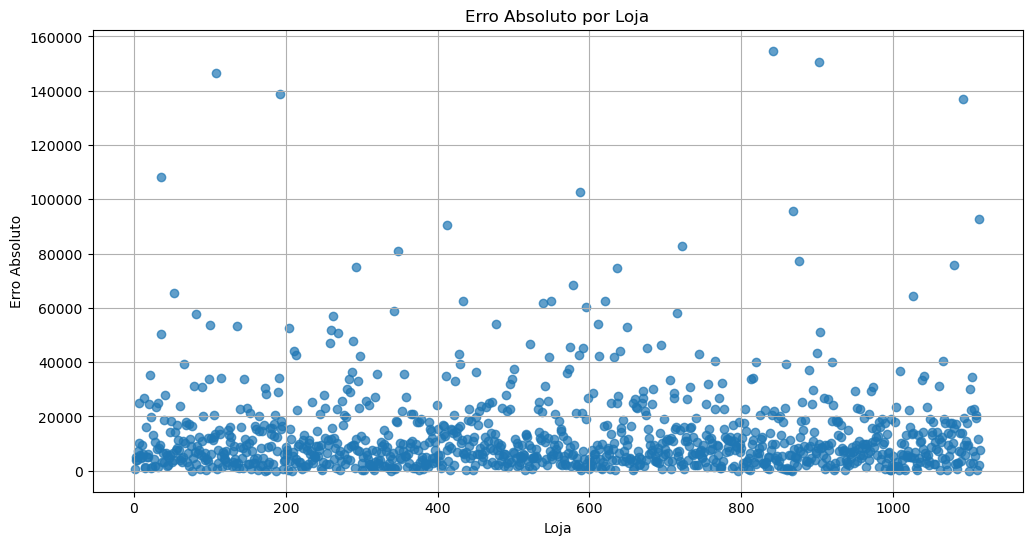

In [ ]:
# Gráfico: Erro absoluto por loja (maiores erros merecem atenção)
plt.figure(figsize=(12, 6))
plt.scatter(
    df_mae_loja_sorted['IdStore'], 
    df_mae_loja_sorted['erro_abs'], 
    alpha=0.7
)
plt.xlabel('Loja')
plt.ylabel('Erro Absoluto')
plt.title('Erro Absoluto por Loja')
plt.grid(True)
plt.show()

## Interpretação do Erro do Modelo


In [ ]:
# Calcula o erro absoluto e a razão entre previsão e valor real
test_df.loc[:, "error"] = test_df["Target"] - test_df["y_pred"]
test_df.loc[:, "error_rate"] = test_df["y_pred"] / test_df["Target"]

C:\Users\patry\AppData\Local\Temp\ipykernel_2344\1938775510.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['DtRef'] = pd.to_datetime(test_df['DtRef'])


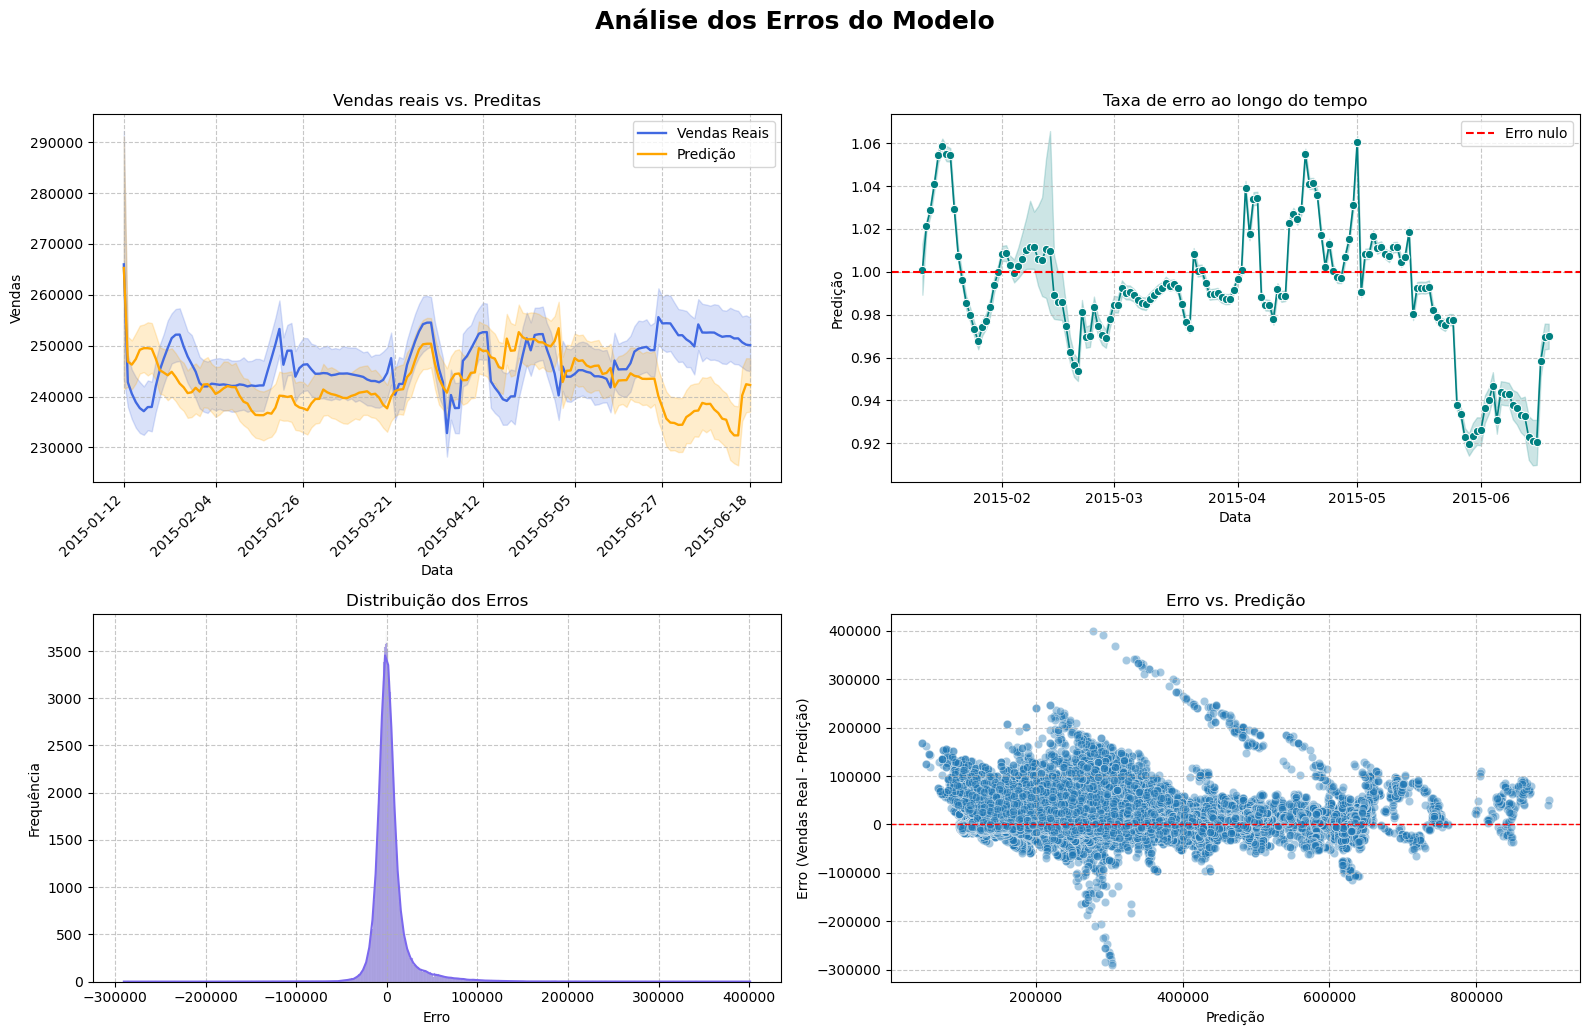

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Garantir que a coluna de datas está no formato datetime
test_df['DtRef'] = pd.to_datetime(test_df['DtRef'])

# Gráfico 1: Vendas reais vs. preditas
sns.lineplot(
    x='DtRef', y='Target', data=test_df, label='Vendas Reais',
    ax=axes[0, 0], color='royalblue', linewidth=1.7
)
sns.lineplot(
    x='DtRef', y='y_pred', data=test_df, label='Predição',
    ax=axes[0, 0], color='orange', linewidth=1.7
)
axes[0, 0].set_title('Vendas reais vs. Preditas')
axes[0, 0].set_xlabel('Data')
axes[0, 0].set_ylabel('Vendas')
axes[0, 0].legend()
axes[0, 0].grid(linestyle='--', alpha=0.7)

# Ajustar os ticks do eixo x para uma visualização melhor
num_ticks = 8
xticks = np.linspace(0, len(test_df['DtRef']) - 1, num_ticks, dtype=int)
axes[0, 0].set_xticks(test_df['DtRef'].iloc[xticks])
axes[0, 0].set_xticklabels(
    test_df['DtRef'].iloc[xticks].dt.strftime('%Y-%m-%d'),
    rotation=45, ha='right'
)

# Gráfico 2: Taxa de erro ao longo do tempo
sns.lineplot(
    x='DtRef', y='error_rate', data=test_df, marker='o',
    ax=axes[0, 1], color='teal', linewidth=1.2
)
axes[0, 1].axhline(1, linestyle='--', color='red', label='Erro nulo')
axes[0, 1].set_title('Taxa de erro ao longo do tempo')
axes[0, 1].set_xlabel('Data')
axes[0, 1].set_ylabel('Predição')
axes[0, 1].legend()
axes[0, 1].grid(linestyle='--', alpha=0.7)

# Gráfico 3: Distribuição dos erros
sns.histplot(test_df['error'], kde=True, color='mediumslateblue', ax=axes[1, 0])
axes[1, 0].set_title('Distribuição dos Erros')
axes[1, 0].set_xlabel('Erro')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].grid(linestyle='--', alpha=0.7)

# Gráfico 4: Erro vs. Predição
sns.scatterplot(
    x='y_pred', y='error', data=test_df, ax=axes[1, 1], alpha=0.4
)
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_title('Erro vs. Predição')
axes[1, 1].set_xlabel('Predição')
axes[1, 1].set_ylabel('Erro (Vendas Real - Predição)')
axes[1, 1].grid(linestyle='--', alpha=0.7)

plt.suptitle(
    'Análise dos Erros do Modelo',
    fontsize=18, y=1.03, fontweight='bold'
)
plt.tight_layout()
plt.show()

 
 **1. Vendas Reais vs. Preditas**
 
 - O gráfico compara a evolução das vendas reais com as previsões do modelo ao longo do período de teste.
 
 - As duas curvas apresentam comportamento semelhante na maior parte do período, indicando que o modelo consegue acompanhar **a tendência geral das vendas**. As previsões também acompanham diversos picos e quedas observados nas vendas reais.
 
 - Entretanto, em alguns períodos existe uma diferença maior entre as curvas, principalmente em momentos de maior variação das vendas. Isso indica que o modelo apresenta maior dificuldade em capturar **variações mais abruptas ou comportamentos pontuais**.
 
 - De forma geral, a proximidade entre as curvas indica que o modelo consegue reproduzir adequadamente o comportamento temporal das vendas.
 
 **2. Taxa de Erro ao Longo do Tempo**
 
 - Este gráfico apresenta a razão entre a previsão e o valor real, sendo **1 o ponto de previsão perfeita**.
 
 - Observa-se que a taxa permanece próxima de 1 durante grande parte do período, indicando que as previsões apresentam boa proximidade dos valores reais.
 
 - Em alguns momentos, a taxa fica acima de 1, indicando **superestimação das vendas**, enquanto em outros períodos fica abaixo de 1, indicando **subestimação**.
 
 - Também é possível observar maior oscilação em determinados períodos, principalmente no início e no final da série. No final do período, a taxa permanece predominantemente abaixo de 1, indicando uma tendência de **subestimação das vendas no período mais recente**.
 
 **3. Distribuição dos Erros**
 
 - A distribuição dos erros apresenta uma concentração muito forte próxima de **zero**, indicando que a maior parte das previsões possui erros relativamente pequenos.
 
 - A distribuição, entretanto, apresenta **caudas para ambos os lados**, com alguns erros extremos positivos e negativos. Isso indica a existência de observações nas quais o modelo apresentou diferenças significativamente maiores entre as vendas reais e previstas.
 
 - Como o erro foi calculado como `Target - y_pred`, valores **positivos representam subestimação** e valores **negativos representam superestimação**.
 
 - A concentração dos erros em torno de zero reforça o bom desempenho geral do modelo, enquanto as caudas indicam a presença de alguns casos específicos que merecem investigação.
 
 **4. Erro vs. Predição**
 
 - O gráfico relaciona o erro obtido com o valor previsto pelo modelo.
 
 - A maior parte das observações está concentrada próxima da linha de erro zero, mostrando que, para a maioria das previsões, a diferença entre o valor real e o previsto é relativamente pequena.
 
 - Por outro lado, observa-se que a dispersão dos erros aumenta em determinadas faixas de previsão, principalmente em valores mais elevados. Também existem alguns pontos extremos, indicando que o modelo apresenta maior dificuldade em algumas previsões de maior magnitude.
 
 - Além disso, há uma concentração de erros positivos em algumas faixas de valores previstos, indicando situações em que o modelo tende a **subestimar vendas mais elevadas**.
 
 **Conclusão da Análise de Erros**
 
 - De forma geral, os gráficos indicam que o modelo apresenta **boa capacidade de acompanhar o comportamento das vendas e mantém os erros concentrados próximos de zero**.
 
 - Os principais pontos de atenção são os **erros extremos**, a maior dispersão em determinadas faixas de previsão e a tendência de subestimação observada no final do período. Esses casos podem estar relacionados a lojas ou períodos com comportamentos atípicos, sendo candidatos para uma investigação mais detalhada.


# Conclusão

Um **modelo de Machine Learning para previsão de vendas** capaz de estimar o **valor total das vendas dos próximos 42 dias (seis semanas)** para cada loja de uma rede de farmácias.

O modelo final, baseado em **XGBoost**, alcançou **R² de 0,9461** e **MAPE de 5,20% no conjunto Out-of-Time (OOT)**, demonstrando alto poder preditivo e consistência na previsão de um período mais recente.

**Destaques**

* **R²: 0,9461** | **MAPE: 5,20%** no conjunto OOT

* **MAE: R$ 12.895,76** e **RMSE: R$ 20.822,40** no OOT

* Previsão do **valor total de vendas para 42 dias** por loja

* **240 variáveis** construídas a partir de histórico de vendas, clientes, promoções, feriados, características das lojas e comportamento temporal

* Feature Store organizada por **loja e data de referência**

* **XGBoost selecionado** pelo equilíbrio entre desempenho preditivo, generalização e eficiência de treinamento

* **Otimização com Optuna**, utilizando 50 trials para ajuste dos hiperparâmetros


**Problema de Negócio**

**Estimar as vendas futuras de cada loja** para apoiar decisões estratégicas relacionadas a investimentos, expansão, reformas e campanhas de marketing.

**Target:** Valor total das vendas acumuladas nos **42 dias seguintes à data de referência**.

**Saída:** Valor previsto de vendas para cada loja durante as seis semanas seguintes.


**Dados e Infraestrutura**

O projeto combina duas principais fontes de dados:

* `sales` — Vendas diárias, clientes, funcionamento da loja, promoções e feriados (**1.017.209 registros**)

* `store` — Características das lojas, sortimento, concorrência e informações sobre Promo2 (**1.115 lojas**)

Os dados foram transformados em uma **Feature Store**, organizada por **loja e data de referência**, e posteriormente utilizados na construção da base analítica para modelagem.


**Solução**

Foi desenvolvido um **pipeline de previsão baseado em Feature Store**, utilizando SQL e Python.

As variáveis foram organizadas em quatro principais grupos:

* **Vendas:** Histórico de vendas, estatísticas móveis, sazonalidade e indicadores de crescimento

* **Clientes:** Volume, variabilidade e indicadores de crescimento de clientes

* **Temporal:** Funcionamento da loja, promoções e feriados

* **Loja:** Tipo, sortimento, concorrência e participação em programas promocionais

Foram utilizadas janelas históricas de **7, 14, 28, 42, 56 e 84 dias**, permitindo capturar comportamentos de curto e longo prazo.

**Prevenção de Data Leakage:** As variáveis históricas foram construídas utilizando apenas informações disponíveis até a respectiva data de referência.


**Seleção e Tuning do Modelo**

Foram avaliados quatro modelos de regressão:

* Gradient Boosting
* AdaBoost
* Random Forest
* XGBoost

Embora o **Gradient Boosting** tenha apresentado as melhores métricas iniciais no conjunto de teste, o **XGBoost foi selecionado** por apresentar desempenho competitivo na validação, maior proximidade entre validação e teste e menor tempo de treinamento.

Em seguida, o XGBoost foi otimizado utilizando **Optuna**, com **50 trials** e o **MAE no conjunto de validação como objetivo de otimização**.

A melhor configuração foi encontrada no **trial 46**, com MAE de aproximadamente **R$ 20.022,60 na validação**.


**Desempenho do Modelo**

Após o tuning, o modelo foi retreinado utilizando os conjuntos de **treino e validação combinados**, mantendo o período OOT completamente separado.

| Métrica  |        Teste |          OOT |
| -------- | -----------: | -----------: |
| **R²**   |   **0,9469** |   **0,9461** |
| **MAE**  | R$ 11.065,86 | R$ 12.895,76 |
| **MAPE** |    **4,51%** |    **5,20%** |
| **RMSE** | R$ 20.292,75 | R$ 20.822,40 |

A proximidade dos resultados entre Teste e OOT indica **boa capacidade de generalização**, além de estabilidade ao realizar previsões em um período mais recente que não foi utilizado durante o treinamento ou tuning.


**Análise dos Erros**

A análise dos erros foi realizada tanto no nível das observações quanto no nível das lojas.

A maior parte das previsões apresentou erros concentrados próximos de zero, indicando que o modelo possui **boa precisão para a maioria das observações**.

Na análise por loja, a maior parte dos erros absolutos permaneceu abaixo de aproximadamente **R$ 20 mil**. Entretanto, algumas lojas apresentaram erros significativamente maiores, chegando a aproximadamente **R$ 155 mil**.

Também foi identificada uma tendência de **subestimação das vendas no período mais recente**, além de maior dispersão dos erros em algumas previsões de maior valor.

Esses casos representam oportunidades para análises futuras, principalmente em lojas que apresentam **comportamentos atípicos ou maior variabilidade nas vendas**.


**Principais Resultados**

✓ **R² de 0,9461 e MAPE de 5,20%** no período OOT

✓ Previsão de vendas para os **42 dias seguintes** de cada loja

✓ **240 variáveis** abrangendo vendas, clientes, comportamento temporal e características das lojas

✓ **Otimização com Optuna** utilizando 50 trials

✓ **Boa generalização** entre os conjuntos de Teste e OOT

✓ Maioria das previsões apresenta **baixo erro absoluto**, com os erros concentrados próximos de zero

✓ Identificação de lojas e períodos com **maiores erros de previsão**, possibilitando investigações futuras


**Pipeline de Execução**

```text
Dados Brutos
    ↓
Exploração
    ↓
Engenharia de Features
    ↓
Feature Store
    ↓
Base Analítica (ABT)
    ↓
Pipeline de Pré-processamento
    ↓
Comparação de Modelos
    ↓
Seleção do XGBoost
    ↓
Tuning com Optuna
    ↓
Modelo Final
    ↓
Avaliação Teste + OOT
    ↓
Análise dos Erros
    ↓
Previsão de Vendas
```
